In [3]:
import pandas as pd
import numpy as np
import glob  # Ensure glob module is imported
import re
import matplotlib.pyplot as plt

In [9]:
# --- 1. Load Data ---
# Load the example trading data files
file_pattern = './data/dbeq-basic-*.trades.csv'
file_paths = glob.glob(file_pattern)

In [10]:
dataframes = {}
for file_path in file_paths:
    date_key = re.search(r'\d{8}', file_path).group(0) if re.search(r'\d{8}', file_path) else 'unknown'
    df = pd.read_csv(file_path)[['ts_event', 'price', 'size']]  # Use only necessary columns
    df['ts_event'] = pd.to_datetime(df['ts_event']).dt.tz_localize(None)
    dataframes[date_key] = df

In [11]:
# Select a specific day for processing (e.g., first file)
selected_day_key = list(dataframes.keys())[0]  # Pick the first day's data
trade_data = dataframes[selected_day_key]

# --- 2. Preprocess Data ---
# Filter trades to include only the regular trading session (13:30 to 20:00 UTC)
trade_data['time'] = trade_data['ts_event'].dt.time
trade_data = trade_data[
    (trade_data['time'] >= pd.to_datetime("13:30:00").time()) & 
    (trade_data['time'] <= pd.to_datetime("20:00:00").time())
]

# Resample trades to 1-minute intervals and calculate VWAP for minute prices
trade_data.set_index('ts_event', inplace=True)
minute_data = trade_data.resample('1T').agg({'price': 'mean', 'size': 'sum'})
minute_data['vwap'] = minute_data['price']  # Simplify VWAP calculation with average price

In [12]:
# --- 3. Calculate Transaction Costs ---
eta = 0.1  # Replace with the actual estimated eta
beta = 0.6  # Replace with the actual estimated beta
sigma = 0.02  # Example placeholder for volatility

# Placeholder: Simulate some trades based on minute intervals
example_trades = [
    {'minute': 30, 'action': 'buy', 'size': 100},
    {'minute': 120, 'action': 'sell', 'size': 50},
    {'minute': 180, 'action': 'buy', 'size': 200}
]

In [16]:
def calculate_transaction_cost(trades, minute_data, eta, beta, sigma):
    """
    Calculate transaction costs and P&L for each trade based on real market data.
    
    Parameters:
        trades (list of dict): Each trade includes 'minute', 'action', 'size'.
        minute_data (DataFrame): Minute-level price and volume data.
        eta (float): Temporary impact parameter.
        beta (float): Market impact non-linearity parameter.
        sigma (float): Market volatility.
    
    Returns:
        pd.DataFrame: Contains transaction cost and P&L for each trade.
    """
    results = []
    cumulative_position = 0

    for trade in trades:
        minute = trade['minute']
        action = trade['action']
        size = trade['size']

        # Get minute-level price and volume data
        trade_price = minute_data.iloc[minute]['vwap']
        trade_volume = minute_data.iloc[minute]['size']

        # Direction: +1 for buy, -1 for sell
        direction = 1 if action == 'buy' else -1

        # Temporary and permanent impacts
        temp_impact = eta * sigma * (size / trade_volume) ** beta
        perm_impact = eta * (size / trade_volume)

        # Adjust trade price for market impacts
        execution_price = trade_price + direction * (temp_impact + perm_impact)

        # Calculate transaction cost
        transaction_cost = direction * size * (execution_price - trade_price)

        # Calculate realized P&L
        realized_pnl = -direction * size * execution_price

        # Update cumulative position
        cumulative_position += direction * size

        # Append results
        results.append({
            'Minute': minute,
            'Action': action,
            'Size': size,
            'Market Price': trade_price,
            'Execution Price': execution_price,
            'Transaction Cost': transaction_cost,
            'Realized P&L': realized_pnl,
            'Cumulative Position': cumulative_position
        })

    return pd.DataFrame(results)

In [17]:
# Apply transaction cost calculation
transaction_results = calculate_transaction_cost(example_trades, minute_data, eta, beta, sigma)

print(transaction_results)

   Minute Action  Size  Market Price  Execution Price  Transaction Cost  \
0      30    buy   100    118.238802       118.239544          0.074190   
1     120   sell    50    122.409725       122.409066          0.032939   
2     180    buy   200    122.225660       122.231377          1.143308   

   Realized P&L  Cumulative Position  
0 -11823.954430                  100  
1   6120.453325                   50  
2 -24446.275384                  250  


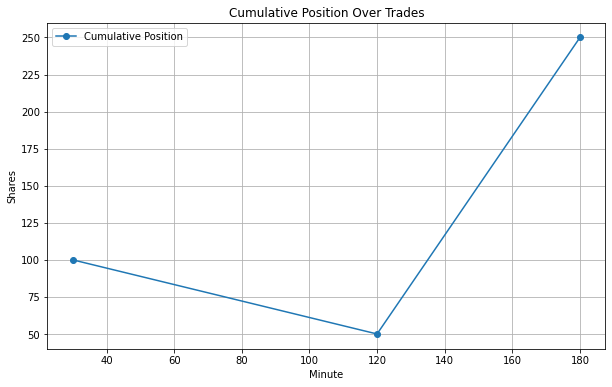

In [18]:
# Visualize cumulative position and transaction costs
# Cumulative Position
plt.figure(figsize=(10, 6))
plt.plot(transaction_results['Minute'], transaction_results['Cumulative Position'], marker='o', label='Cumulative Position')
plt.title('Cumulative Position Over Trades')
plt.xlabel('Minute')
plt.ylabel('Shares')
plt.grid()
plt.legend()
plt.show()

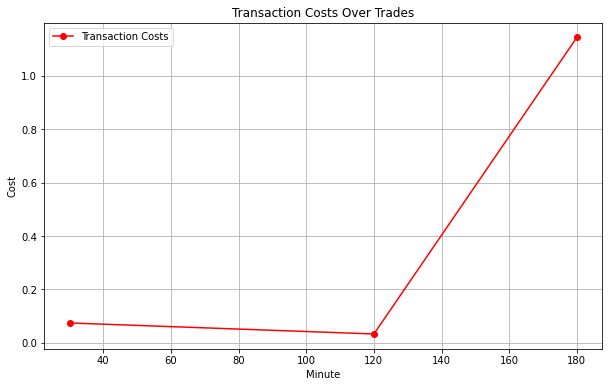

In [19]:
# Transaction Costs
plt.figure(figsize=(10, 6))
plt.plot(transaction_results['Minute'], transaction_results['Transaction Cost'], marker='o', color='red', label='Transaction Costs')
plt.title('Transaction Costs Over Trades')
plt.xlabel('Minute')
plt.ylabel('Cost')
plt.grid()
plt.legend()
plt.show()